In [1]:
#######################################################################
#######################################################################
##
## This notebook is quantifying the HCR total intensity within the cells in the context of HCR Kazald1
## 
#######################################################################
#######################################################################

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
import tifffile

In [3]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage.filters import gaussian
from skimage import morphology
from skimage import measure
from skimage import io, exposure, img_as_ubyte
from skimage.transform import rescale
from skimage.transform import resize

In [4]:
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

In [5]:
import napari
from napari.utils import nbscreenshot

In [6]:
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [7]:
cle.available_device_names()
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [8]:
#import czifile
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter

In [11]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1"

fileName = "11dLNP4-limb3-20x-01(1)-Airyscan Processing-01.czi"
fileName = "11d_LNP4_20x_limb2(1)-Airyscan Processing-02.czi"

fileName = "11dpi_BL_an1_20x_Airyscan_07.czi"
fileName = "11d_LNP4_20x_limb1_Airyscan_03.czi"

outDir = inputDir + '/results/'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/


In [12]:
## read czi file (original code https://biapol.github.io/Image-data-science-with-Python-and-Napari-EPFL2022/day2b_Working_with_Images/04_Image_file_formats.html)
#img = czifile.imread(os.path.join(inputDir, fileName))
#img.shape
#czi_dimstring = img.axes
# shape will give you the dimensions of the array
#czi_shapeinfo = img.shape

In [13]:
## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
img = AICSImage(os.path.join(inputDir, fileName))

In [14]:
image = img.data #returns 6D STCZYX numpy array

In [16]:
print(image.shape)
print(img.dims)  # returns string "STCZYX"
print(img.shape)  # returns tuple of dimension sizes in STCZYX order

(1, 4, 1, 18864, 40489)
<Dimensions [T: 1, C: 4, Z: 1, Y: 18864, X: 40489]>
(1, 4, 1, 18864, 40489)


In [17]:
# Metadata Reading (https://allencellmodeling.github.io/aicsimageio/index.html)
img.channel_names  # returns a list of string channel names found in the metadata

[np.str_('ChA-T1'), np.str_('ChA-T2'), np.str_('ChA-T3'), np.str_('ChA-T4')]

In [18]:
#print(img.physical_pixel_sizes.Z)  # no Z dimension
print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata

0.061810168997668995
0.061810168997668995


In [19]:
hcr_c1 = img.get_image_data("ZYX", C=0, S=0, T=0) # Kazald1, the signal to quantify
prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
lnpGFP_c3 = img.get_image_data("ZYX", C=2, S=0, T=0) # also cytoplasm, marking cells with lnp, in blastema there is no lnp-GFP, because no injection in blatema, even in the CSD, blood cell make autofluerence
dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 

In [20]:
print(dapi_c4.shape)
print(prrxCherry_c2.shape)

(1, 18864, 40489)
(1, 18864, 40489)


In [28]:
## ignore the z stack channel
print(dapi_c4[0].shape)
print(prrxCherry_c2[0].shape)
hcr = hcr_c1[0]
lnpGFP = lnpGFP_c3[0]
cellmarker = prrxCherry_c2[0]
dapi = dapi_c4[0]

(18864, 40489)
(18864, 40489)


In [29]:
print(fileName.removesuffix('.czi'))
print(inputDir)

11d_LNP4_20x_limb1_Airyscan_03
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1


In [26]:
mask = imread(os.path.join(inputDir, str('cell_masks/' + fileName.removesuffix('.czi') + "_8bit_cp_masks.tif")))

In [30]:
mask.shape

(9432, 20244)

In [35]:
mask_upscaled = resize(
    mask,
    output_shape = cellmarker.shape,
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(mask.dtype)

In [36]:
mask_upscaled.shape

(18864, 40489)

In [39]:
np.max(cellmarker)

np.uint16(65535)

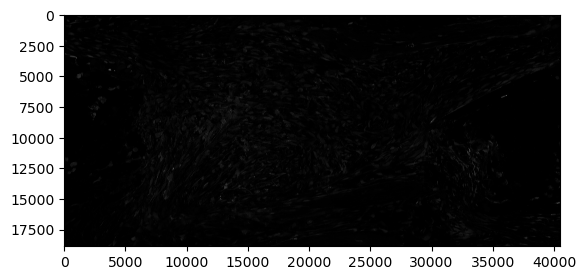

In [40]:
plt.imshow(cellmarker, cmap='gray')

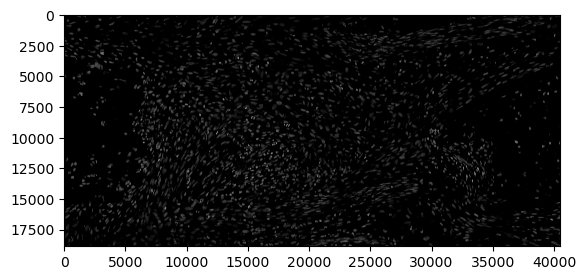

In [41]:
plt.imshow(dapi, cmap='gray')

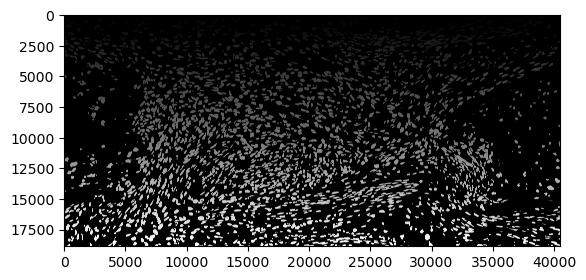

In [42]:
plt.imshow(mask_upscaled, cmap='gray')

In [43]:
labels_mask, nb_mask = measure.label(mask_upscaled, return_num = True)
nb_mask

3928

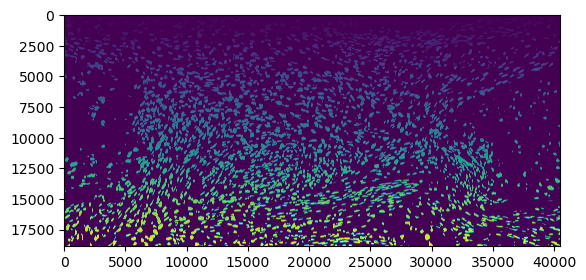

In [68]:
plt.imshow(labels_mask)

In [44]:
## mask image 
props_mask = measure.regionprops_table(
    labels_mask, 
    #intensity_image = C3,
    properties=('label', 'area', 'perimeter', 'equivalent_diameter', 'centroid', 'axis_major_length', 'axis_minor_length', 'euler_number', 'eccentricity', 'solidity'),
)
props_mask = pd.DataFrame(props_mask)
props_mask = props_mask.add_suffix('_mask')

In [45]:
## C1
props_C1 = measure.regionprops_table(
    labels_mask, 
    intensity_image = hcr,
    properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
)
props_C1 = pd.DataFrame(props_C1)
props_C1 = props_C1.add_suffix('_hcr')

## C2
props_C2 = measure.regionprops_table(
    labels_mask, 
    intensity_image = cellmarker,
    properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
)
props_C2 = pd.DataFrame(props_C2)
props_C2 = props_C2.add_suffix('_cellmarker')

props_C3 = measure.regionprops_table(
    labels_mask, 
    intensity_image = lnpGFP,
    properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
)
props_C3 = pd.DataFrame(props_C3)
props_C3 = props_C3.add_suffix('_lnpGFP')

props_C4 = measure.regionprops_table(
    labels_mask, 
    intensity_image = dapi,
    properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
)
props_C4 = pd.DataFrame(props_C4)
props_C4 = props_C4.add_suffix('_dapi')

In [51]:
df = pd.concat([props_mask, props_C1, props_C2, props_C3, props_C4], axis=1)

In [52]:
df

,label_mask,area_mask,perimeter_mask,equivalent_diameter_mask,centroid-0_mask,centroid-1_mask,axis_major_length_mask,axis_minor_length_mask,euler_number_mask,eccentricity_mask,...,intensity_min_cellmarker,intensity_std_cellmarker,intensity_max_lnpGFP,intensity_mean_lnpGFP,intensity_min_lnpGFP,intensity_std_lnpGFP,intensity_max_dapi,intensity_mean_dapi,intensity_min_dapi,intensity_std_dapi
0,1,37724.0,1110.291414,219.161330,54.775899,308.207560,388.821242,144.839245,1,0.928029,...,0.0,1421.603770,1679.0,171.643331,0.0,207.695951,9530.0,2411.745096,0.0,1879.328870
1,2,15800.0,699.894444,141.835062,34.601772,1483.628101,270.684022,81.591749,1,0.953489,...,0.0,272.076165,1822.0,360.876519,0.0,308.627399,5855.0,2580.472532,0.0,925.628632
2,3,15432.0,736.515765,140.173580,29.044323,6980.153707,287.149643,74.084823,1,0.966145,...,0.0,1146.367887,4230.0,741.330093,0.0,568.167456,7629.0,3678.266200,0.0,1659.766285
3,4,16308.0,754.610173,144.097156,27.429605,7633.215232,328.533963,66.238665,1,0.979464,...,0.0,280.484015,2672.0,427.973449,0.0,373.439705,14683.0,5396.891403,0.0,1747.228489
4,5,21932.0,791.492424,167.106821,53.616542,7928.503648,279.186907,110.307474,1,0.918637,...,0.0,281.312783,2187.0,288.792632,0.0,277.608400,9311.0,3176.258025,0.0,1609.963888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3923,3924,4800.0,345.225397,78.176402,18841.950000,11116.616667,130.478120,49.815149,1,0.924249,...,0.0,322.521196,3971.0,1215.896250,0.0,698.974463,4078.0,1566.229167,0.0,715.696497
3924,3925,5612.0,474.461941,84.530588,18848.609765,15095.998218,211.957884,35.888165,1,0.985562,...,0.0,432.376747,3865.0,1243.807912,0.0,676.195479,6315.0,2769.964897,0.0,1087.685014
3925,3926,2300.0,243.769553,54.115164,18847.936522,28113.746957,95.253492,31.901039,1,0.942251,...,0.0,595.383200,1506.0,261.592174,0.0,259.630546,237.0,9.637391,0.0,24.903811
3926,3927,6056.0,526.118795,87.810812,18848.394320,27557.991413,238.472252,33.434166,1,0.990123,...,0.0,1275.700793,2612.0,509.666281,0.0,394.556360,7518.0,2107.373018,0.0,1474.420822


In [55]:
print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/


In [56]:
#df = pd.concat([props_mask, props_C1, props_C2, props_C3, props_C4], axis=1)
df.to_csv(os.path.join(outDir, str(fileName.removesuffix('.czi') +  "_parameterCollection_HCRintensity.csv")), index=True, header=True)

In [58]:
labels_mask.shape, cellmarker.shape, dapi.shape

((18864, 40489), (18864, 40489), (18864, 40489))

In [64]:
# Stack them into a (channels, height, width) image
three_channel_image = np.stack([mask_upscaled, cellmarker, dapi], axis=0)

In [65]:
three_channel_image.shape

(3, 18864, 40489)

In [66]:
# Output two-channel TIFF
output_file = outDir +  fileName.removesuffix('.czi') + "_cellMarker_dapi_mask.tif"
print(output_file)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11d_LNP4_20x_limb1_Airyscan_03_cellMarker_dapi_mask.tif


In [67]:
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    three_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11d_LNP4_20x_li…er_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


In [36]:
## convert 16-bit to 8 bit
from skimage import io, exposure, img_as_ubyte

In [38]:
np.max(cellmarker), np.min(cellmarker)

(np.uint16(65535), np.uint16(0))

In [40]:
#cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
cellmarker8 = img_as_ubyte(cellmarker)
np.max(cellmarker8), np.min(cellmarker8)

(np.uint8(255), np.uint8(0))

In [41]:
dapi8 = img_as_ubyte(dapi)
np.max(dapi8), np.min(dapi8)

(np.uint8(255), np.uint8(0))

In [42]:
output_file = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/" +  fileName.removesuffix('.czi') + "_8bit.tif"
print(output_file)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/11dpi_BL_an1_20x_Airyscan_07_8bit.tif


In [43]:
two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    two_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

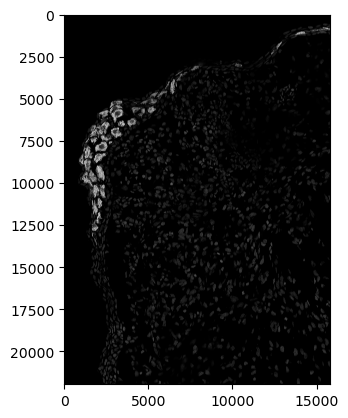

In [44]:
plt.imshow(dapi, cmap='gray')

In [ ]:
#bone_mask_cropped[0:500, 400:1200]

In [48]:
output_file = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/" +  fileName.removesuffix('.czi') + "_8bit_cropped_2.tif"
print(output_file)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/11dpi_BL_an1_20x_Airyscan_07_8bit_cropped_2.tif


In [49]:
two_channel_image = np.stack([cellmarker8[10000:12000, 5000:7000], dapi8[10000:12000, 5000:7000]], axis=0)
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    two_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

In [50]:
two_channel_image.shape

(2, 2000, 2000)

In [ ]:
#########################################################
#########################################################
### here is the save cell markers and dapi for all images 
#########################################################
#########################################################

In [14]:
print(inputDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1


In [15]:
outDir = inputDir + "/images"

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images


In [16]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if ".czi" in nm:
        print(nm)
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('.czi','')
        
        ## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
        img = AICSImage(os.path.join(inputDir, fileName + '.czi'))
        image = img.data #returns 6D STCZYX numpy array
        
        print(image.shape)
        #print(img.dims)  # returns string "STCZYX"
        #print(img.shape)  # returns tuple of dimension sizes in STCZYX order
        print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
        print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata
        
        prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 
        
        print(dapi_c4[0].shape)
        print(prrxCherry_c2[0].shape)
        
        cellmarker = prrxCherry_c2[0]
        dapi = dapi_c4[0]
        
        ## mild denoising
        sigma = 1.0
        cellmarker = gaussian(cellmarker, sigma=sigma)
        dapi = gaussian(dapi, sigma=sigma)
        
        print([np.min(cellmarker), np.max(cellmarker)])
        print([np.min(dapi), np.max(dapi)])
        
        ## convert 16bit to 8bit to reduce the image size
        #cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
        cellmarker8 = img_as_ubyte(cellmarker)
        dapi8 = img_as_ubyte(dapi)
        print([np.min(cellmarker8), np.max(cellmarker8)])
        print([np.min(dapi8), np.max(dapi8)])
        
        ## downsample the images
        factor = 0.5  # downsample to 50%
        cellmarker8 = rescale(cellmarker8, factor, preserve_range=True, anti_aliasing=True, order=1).astype(cellmarker8.dtype)
        dapi8 = rescale(dapi8, factor, preserve_range=True, anti_aliasing = True, order=1).astype(dapi8.dtype)
        
        print(cellmarker8.shape)
        print(dapi8.shape)
        ## save the two channels images
        output_file = os.path.join(outDir, fileName + "_8bit.tif")
        
        print(output_file)
        
        two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
        # Save as an ImageJ-compatible TIFF, labeling axes as CYX
        tifffile.imwrite(
            output_file,
            two_channel_image,
            imagej=True,
            metadata={"axes": "CYX"}
        )
        

11dpi_LNP2_an2_20x_Airyscan_09.czi
(1, 4, 1, 18877, 68296)
0.061810168997668995
0.061810168997668995
(18877, 68296)
(18877, 68296)
[np.float64(0.0), np.float64(0.9932205968451748)]
[np.float64(0.0), np.float64(0.537209744373853)]
[np.uint8(0), np.uint8(253)]
[np.uint8(0), np.uint8(137)]
(9438, 34148)
(9438, 34148)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images/11dpi_LNP2_an2_20x_Airyscan_09_8bit.tif
11d_LNP3_20x_limb2_Airyscan_09.czi
(1, 4, 1, 22024, 52847)
0.061810168997668995
0.061810168997668995
(22024, 52847)
(22024, 52847)
[np.float64(0.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.7255450664265867)]
[np.uint8(0), np.uint8(255)]
[np.uint8(0), np.uint8(185)]
(11012, 26424)
(11012, 26424)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images/11d_LNP3_20x_limb2_Airyscan_09_8bit.tif
11d_LNP3_20x_limb1__Airyscan_05.czi
(1, 4, 1, 18868, 40489)
0.061810168997668995
0.0618101

In [ ]:
#########################################################
#########################################################
### here is parameter collection based on the cell masks from cellpose
#########################################################
#########################################################

In [71]:
outDir = inputDir + '/results/'

if not os.path.exists(outDir):
    os.makedirs(outDir)
print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/


In [72]:
print(inputDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1


In [73]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if ".czi" in nm:
        print('--------------------------------------')
        print(nm)
        
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('.czi','')
        
        ## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
        img = AICSImage(os.path.join(inputDir, fileName + '.czi'))
        image = img.data #returns 6D STCZYX numpy array
        
        print(image.shape)
        #print(img.dims)  # returns string "STCZYX"
        #print(img.shape)  # returns tuple of dimension sizes in STCZYX order
        print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
        print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata
        
        #prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        #dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 
        
        hcr_c1 = img.get_image_data("ZYX", C=0, S=0, T=0) # Kazald1, the signal to quantify
        prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        lnpGFP_c3 = img.get_image_data("ZYX", C=2, S=0, T=0) # also cytoplasm, marking cells with lnp, in blastema there is no lnp-GFP, because no injection in blatema, even in the CSD, blood cell make autofluerence
        dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 

        #print(dapi_c4[0].shape)
        #print(prrxCherry_c2[0].shape)
        
        print(dapi_c4[0].shape)
        print(prrxCherry_c2[0].shape)
        hcr = hcr_c1[0]
        lnpGFP = lnpGFP_c3[0]
        cellmarker = prrxCherry_c2[0]
        dapi = dapi_c4[0]

        #cellmarker = prrxCherry_c2[0]
        #dapi = dapi_c4[0]
        
        ## import corresponding cell masks
        mask = imread(os.path.join(inputDir, str('cell_masks/' + fileName.removesuffix('.czi') + "_8bit_cp_masks.tif")))
        
        print('upscale the mask')
        mask_upscaled = resize(
            mask,
            output_shape = cellmarker.shape,
            order=0,
            preserve_range=True,
            anti_aliasing=False
        ).astype(mask.dtype)
        
        print(mask_upscaled.shape)
        
        labels_mask, nb_mask = measure.label(mask_upscaled, return_num = True)
        print('nb of cells segmented : ' + str(nb_mask))
        
        ## mask image 
        props_mask = measure.regionprops_table(
            labels_mask, 
            #intensity_image = C3,
            properties=('label', 'area', 'perimeter', 'equivalent_diameter', 'centroid', 'axis_major_length', 'axis_minor_length', 'euler_number', 'eccentricity', 'solidity'),
        )
        props_mask = pd.DataFrame(props_mask)
        props_mask = props_mask.add_suffix('_mask')

        ## C1
        props_C1 = measure.regionprops_table(
            labels_mask, 
            intensity_image = hcr,
            properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
        )
        props_C1 = pd.DataFrame(props_C1)
        props_C1 = props_C1.add_suffix('_hcr')

        ## C2
        props_C2 = measure.regionprops_table(
            labels_mask, 
            intensity_image = cellmarker,
            properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
        )
        props_C2 = pd.DataFrame(props_C2)
        props_C2 = props_C2.add_suffix('_cellmarker')

        props_C3 = measure.regionprops_table(
            labels_mask, 
            intensity_image = lnpGFP,
            properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
        )
        props_C3 = pd.DataFrame(props_C3)
        props_C3 = props_C3.add_suffix('_lnpGFP')

        props_C4 = measure.regionprops_table(
            labels_mask, 
            intensity_image = dapi,
            properties=('intensity_max', 'intensity_mean', 'intensity_min', 'intensity_std'),
        )
        props_C4 = pd.DataFrame(props_C4)
        props_C4 = props_C4.add_suffix('_dapi')
        
        ## save the parameter table
        df = pd.concat([props_mask, props_C1, props_C2, props_C3, props_C4], axis=1)
        df.to_csv(os.path.join(outDir, str(fileName.removesuffix('.czi') +  "_parameterCollection_HCRintensity.csv")), index=True, header=True)
        
        ## save the mask, cellmarker and dapi 
        three_channel_image = np.stack([mask_upscaled, cellmarker, dapi], axis=0)
        
        output_file = os.path.join(outDir, fileName + "_cellMarker_dapi_mask.tif")
        print(output_file)
        
        # Save as an ImageJ-compatible TIFF, labeling axes as CYX
        tifffile.imwrite(
            output_file,
            three_channel_image,
            imagej=True,
            metadata={"axes": "CYX"}
        )
        

--------------------------------------
11dpi_LNP2_an2_20x_Airyscan_09.czi
(1, 4, 1, 18877, 68296)
0.061810168997668995
0.061810168997668995
(18877, 68296)
(18877, 68296)
upscale the mask
(18877, 68296)
nb of cells segmented : 17767
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11dpi_LNP2_an2_20x_Airyscan_09_cellMarker_dapi_mask.tif


/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11dpi_LNP2_an2_…er_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


--------------------------------------
11d_LNP3_20x_limb2_Airyscan_09.czi
(1, 4, 1, 22024, 52847)
0.061810168997668995
0.061810168997668995
(22024, 52847)
(22024, 52847)
upscale the mask
(22024, 52847)
nb of cells segmented : 5399
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11d_LNP3_20x_limb2_Airyscan_09_cellMarker_dapi_mask.tif


/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11d_LNP3_20x_li…er_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


--------------------------------------
11d_LNP3_20x_limb1__Airyscan_05.czi
(1, 4, 1, 18868, 40489)
0.061810168997668995
0.061810168997668995
(18868, 40489)
(18868, 40489)
upscale the mask
(18868, 40489)
nb of cells segmented : 3170
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11d_LNP3_20x_limb1__Airyscan_05_cellMarker_dapi_mask.tif


...

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11dpi_LNP2_an3_…er_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


--------------------------------------
11d_LNP4_20x_limb1_Airyscan_03.czi
(1, 4, 1, 18864, 40489)
0.061810168997668995
0.061810168997668995
(18864, 40489)
(18864, 40489)
upscale the mask
(18864, 40489)
nb of cells segmented : 3928
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11d_LNP4_20x_limb1_Airyscan_03_cellMarker_dapi_mask.tif


/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11d_LNP4_20x_li…er_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


--------------------------------------
11dLNP4_limb3_20x_Airyscan_01.czi
(1, 4, 1, 25038, 37401)
0.061810168997668995
0.061810168997668995
(25038, 37401)
(25038, 37401)
upscale the mask
(25038, 37401)
nb of cells segmented : 4004
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/11dLNP4_limb3_20x_Airyscan_01_cellMarker_dapi_mask.tif


/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/tifffile/tifffile.py:3779: UserWarning: <tifffile.TiffWriter '11dLNP4_limb3_20…r_dapi_mask.tif'> truncating ImageJ file
  warnings.warn(


In [ ]:
#########################################################
#########################################################
### section: compare the cellpose mask with cellmarkers and dapi
#########################################################
#########################################################

In [ ]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1"

fileName = "11dLNP4-limb3-20x-01(1)-Airyscan Processing-01.czi"
fileName = "11d_LNP4_20x_limb2(1)-Airyscan Processing-02.czi"

fileName = "11dpi_BL_an1_20x_Airyscan_07.czi"
fileName = "11d_LNP4_20x_limb1_Airyscan_03.czi"

outDir = inputDir + '/results/'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

In [9]:
print(inputDir)

NameError: name 'inputDir' is not defined

In [ ]:
#########################################################
#########################################################
### to reduce the image sizes, try to crop the image size based on. the region of interest  
#########################################################
#########################################################

In [17]:
outDir = inputDir + "/images_cropped"
if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped


In [73]:
crop_coord = pd.read_csv("/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/HCR_crop_coordinates.csv", sep = ";")

In [74]:
crop_coord

,file,point1_X,point1_Y,point2_X,point2_Y,point3_X,point3_Y,point4_X,point4_Y
0,11d_LNP3_20x_limb1__Airyscan_05.czi,414,243,435,851,2110,491,2072,1013
1,11d_LNP3_20x_limb3_Airyscan_04.czi,134,79,129,290,1173,78,1091,356
2,11d_LNP4_20x_limb1_Airyscan_03.czi,403,263,389,855,1851,467,2080,1036
3,11d_LNP4_20x_limb2_Airyscan_02.czi,116,110,145,346,797,150,878,350
4,11dLNP4_limb3_20x_Airyscan_01.czi,395,424,463,1320,1854,175,1911,1068
5,11dpi_BL_an1_20x_Airyscan_07.czi,561,198,168,516,969,518,722,874
6,11dpi_BL_an2_20x_Airyscan_06.czi,354,587,710,866,897,399,1242,627
7,11dpi_LNP1_20x_an2_Airyscan_12.czi,123,6,146,238,1066,41,1007,268
8,11dpi_LNP1_20x_an3_Airyscan_11.czi,118,30,160,276,1088,39,1074,226
9,11dpi_LNP1_20x_Airyscan_13.czi,102,131,187,339,1207,51,1194,258


In [75]:
#crop_coord.loc[5, :]

In [76]:
nm = "11d_LNP4_20x_limb1_Airyscan_03.czi"

In [77]:
index = crop_coord.index[crop_coord["file"] == nm]
print(index)

Index([2], dtype='int64')


In [78]:
crop = crop_coord.loc[index, :]
crop = crop.to_numpy()
crop = crop[0, 1:].astype(int)

In [79]:
print(crop.shape)
crop

(8,)


array([ 403,  263,  389,  855, 1851,  467, 2080, 1036])

In [80]:
crop_x = crop[[0, 2, 4, 6]]
crop_y = crop[[1, 3, 5, 7]]
print(crop_x)
print(crop_y)

[ 403  389 1851 2080]
[ 263  855  467 1036]


In [81]:
crop_px_x = np.round(crop_x/0.061810168997668995).astype(int)
crop_px_y = np.round(crop_y/0.061810168997668995).astype(int)

In [82]:
print(crop_px_x)
print(crop_px_y)

[ 6520  6293 29947 33651]
[ 4255 13833  7555 16761]


In [71]:
np.round(crop_px_x).astype(int)

array([ 6520,  6293, 29947, 33651])

In [83]:
outDir = inputDir + "/images_cropped"
if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped


In [84]:
crop_coord = pd.read_csv("/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/HCR_crop_coordinates.csv", sep = ";")

In [85]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if ".czi" in nm:
        print('--------------------------------------')
        print(nm)
        
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('.czi','')
        
        ## find the matching crop coordinates
        index = crop_coord.index[crop_coord["file"] == nm]
        print(index)
        
        crop = crop_coord.loc[index, :]
        crop = crop.to_numpy()
        crop = crop[0, 1:].astype(int)
        crop_x = crop[[0, 2, 4, 6]]
        crop_y = crop[[1, 3, 5, 7]]
        print(crop_x)
        print(crop_y)
        
        ## convert the micron to pixel coordinates
        crop_px_x = np.round(crop_x/0.061810168997668995).astype(int)
        crop_px_y = np.round(crop_y/0.061810168997668995).astype(int)
        print(crop_px_x)
        print(crop_px_y)
        
        ## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
        img = AICSImage(os.path.join(inputDir, fileName + '.czi'))
        image = img.data #returns 6D STCZYX numpy array
        
        print(image.shape)
        #print(img.dims)  # returns string "STCZYX"
        #print(img.shape)  # returns tuple of dimension sizes in STCZYX order
        print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
        print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata
        
        prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 
        
        print(dapi_c4[0].shape)
        print(prrxCherry_c2[0].shape)
        
        cellmarker = prrxCherry_c2[0]
        dapi = dapi_c4[0]
        
        ## mild denoising
        print('-- denoising with gaussian filter --')
        sigma = 1.0
        cellmarker = gaussian(cellmarker, sigma=sigma)
        dapi = gaussian(dapi, sigma=sigma)
        
        print([np.min(cellmarker), np.max(cellmarker)])
        print([np.min(dapi), np.max(dapi)])
        
        ## convert 16bit to 8bit to reduce the image size
        #cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
        print('-- converting 16bit to 8 bit --')
        cellmarker8 = img_as_ubyte(cellmarker)
        dapi8 = img_as_ubyte(dapi)
        print([np.min(cellmarker8), np.max(cellmarker8)])
        print([np.min(dapi8), np.max(dapi8)])
        
        ## downsample the images
        #factor = 0.5  # downsample to 50%
        #cellmarker8 = rescale(cellmarker8, factor, preserve_range=True, anti_aliasing=True, order=1).astype(cellmarker8.dtype)
        #dapi8 = rescale(dapi8, factor, preserve_range=True, anti_aliasing = True, order=1).astype(dapi8.dtype)
        
        ## manual crop by specifying the y-axis and x-axis based on Nastya's manual coordinates
        # e.g. bone_mask_cropped = bone_mask_cropped[0:500, 400:1200]
        print('-- cropping --')
        cellmarker8 = cellmarker8[np.min(crop_px_y):np.max(crop_px_y), np.min(crop_px_x):np.max(crop_px_x)]
        dapi8 = dapi8[np.min(crop_px_y):np.max(crop_px_y), np.min(crop_px_x):np.max(crop_px_x)]
        
        print(cellmarker8.shape)
        print(dapi8.shape)
        
        ## save the two channels images
        output_file = os.path.join(outDir, fileName + "_8bit_cropped.tif")
        
        print(output_file)
        
        two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
        # Save as an ImageJ-compatible TIFF, labeling axes as CYX
        tifffile.imwrite(
            output_file,
            two_channel_image,
            imagej=True,
            metadata={"axes": "CYX"}
        )
        

11dpi_LNP2_an2_20x_Airyscan_09.czi
Index([11], dtype='int64')
[ 256  171 1266 1242]
[128 287 127 334]
[ 4142  2767 20482 20094]
[2071 4643 2055 5404]
(1, 4, 1, 18877, 68296)
0.061810168997668995
0.061810168997668995
(18877, 68296)
(18877, 68296)
-- denoising with gaussian filter --
[np.float64(0.0), np.float64(0.9932205968451748)]
[np.float64(0.0), np.float64(0.537209744373853)]
-- converting 16bit to 8 bit --
[np.uint8(0), np.uint8(253)]
[np.uint8(0), np.uint8(137)]
-- cropping --
(3349, 17715)
(3349, 17715)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped/11dpi_LNP2_an2_20x_Airyscan_09_8bit_cropped.tif
11d_LNP3_20x_limb2_Airyscan_09.czi
Index([13], dtype='int64')
[105  68 738 726]
[101 273  34 198]
[ 1699  1100 11940 11746]
[1634 4417  550 3203]
(1, 4, 1, 22024, 52847)
0.061810168997668995
0.061810168997668995
(22024, 52847)
(22024, 52847)
-- denoising with gaussian filter --
[np.float64(0.0), np.float64(1.0)]
[np.float6